In [1]:
!pip install opendatasets

In [2]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: borshadas
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign


100%|██████████| 612M/612M [00:01<00:00, 409MB/s]


In [3]:
import numpy as np
import os
import pandas as pd
from sklearn.metrics import confusion_matrix
import seaborn as sn; sn.set(font_scale=1.4)
from sklearn.utils import shuffle
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

In [4]:
data_dir = "/content/gtsrb-german-traffic-sign/"

In [5]:
train_csv = pd.read_csv(os.path.join(data_dir, "Train.csv"))

In [6]:
train_csv.head()


,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,27,26,5,5,22,20,20,Train/20/00020_00000_00000.png
1,28,27,5,6,23,22,20,Train/20/00020_00000_00001.png
2,29,26,6,5,24,21,20,Train/20/00020_00000_00002.png
3,28,27,5,6,23,22,20,Train/20/00020_00000_00003.png
4,28,26,5,5,23,21,20,Train/20/00020_00000_00004.png


In [7]:
print(train_csv["ClassId"].value_counts())


ClassId
2     2250
1     2220
13    2160
12    2100
38    2070
10    2010
4     1980
5     1860
25    1500
9     1470
7     1440
3     1410
8     1410
11    1320
35    1200
18    1200
17    1110
14     780
31     780
33     689
15     630
26     600
28     540
23     510
30     450
6      420
16     420
34     420
22     390
36     390
20     360
40     360
21     330
39     300
29     270
24     270
42     240
32     240
27     240
41     240
0      210
19     210
37     210
Name: count, dtype: int64


In [8]:
nb_classes = train_csv["ClassId"].nunique()
print("Number of classes:", nb_classes)
classes = {
    0:'Speed limit (20km/h)', 1:'Speed limit (30km/h)', 2:'Speed limit (50km/h)',
    3:'Speed limit (60km/h)', 4:'Speed limit (70km/h)', 5:'Speed limit (80km/h)',
    6:'End of speed limit (80km/h)', 7:'Speed limit (100km/h)', 8:'Speed limit (120km/h)',
    9:'No passing', 10:'No passing veh over 3.5 tons', 11:'Right-of-way at intersection',
    12:'Priority road', 13:'Yield', 14:'Stop', 15:'No vehicles', 16:'Veh > 3.5 tons prohibited',
    17:'No entry', 18:'General caution', 19:'Dangerous curve left', 20:'Dangerous curve right',
    21:'Double curve', 22:'Bumpy road', 23:'Slippery road', 24:'Road narrows on the right',
    25:'Road work', 26:'Traffic signals', 27:'Pedestrians', 28:'Children crossing',
    29:'Bicycles crossing', 30:'Beware of ice/snow', 31:'Wild animals crossing',
    32:'End speed + passing limits', 33:'Turn right ahead', 34:'Turn left ahead',
    35:'Ahead only', 36:'Go straight or right', 37:'Go straight or left', 38:'Keep right',
    39:'Keep left', 40:'Roundabout mandatory', 41:'End of no passing', 42:'End no passing veh > 3.5 tons'
}

Number of classes: 43


In [9]:
class_names_label = classes
print("Class 2 means:", class_names_label[2])

Class 2 means: Speed limit (50km/h)


In [10]:
IMAGE_SIZE = (64, 64)
def load_data(df, base_dir):
    images = []
    labels = []

    for i, row in tqdm(df.iterrows(), total=len(df)):
        img_path = os.path.join(base_dir, row["Path"])
        label = row["ClassId"]

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, IMAGE_SIZE)

        # Normalization
        image = image.astype("float32") / 255.0

        images.append(image)
        labels.append(label)

    images = np.array(images, dtype="float32")
    labels = np.array(labels, dtype="int32")
    return images, labels


# load
test_csv  = pd.read_csv(os.path.join(data_dir, "Test.csv"))

train_images, train_labels = load_data(train_csv, data_dir)
test_images, test_labels = load_data(test_csv, data_dir)

100%|██████████| 12630/12630 [00:04<00:00, 2650.02it/s]


In [11]:
train_images, train_labels = shuffle(train_images, train_labels, random_state=25)

In [12]:
n_train = train_labels.shape[0]
n_test = test_labels.shape[0]

print("Number of training examples:", n_train)
print("Number of testing examples:", n_test)
print("Each image is of size:", IMAGE_SIZE)

Number of training examples: 39209
Number of testing examples: 12630
Each image is of size: (64, 64)


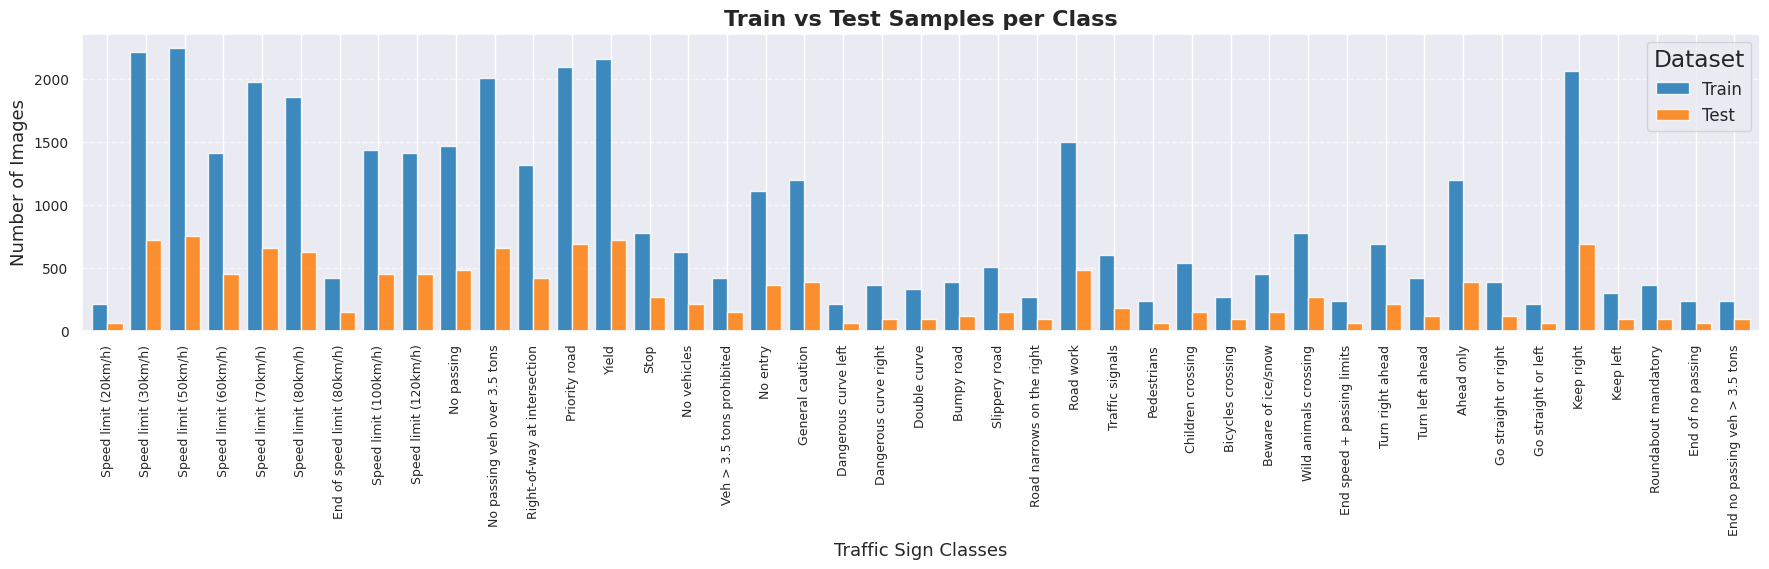

In [13]:
train_ids, train_counts = np.unique(train_labels, return_counts=True)
test_ids, test_counts = np.unique(test_labels, return_counts=True)

df = pd.DataFrame({
    'Train': pd.Series(train_counts, index=train_ids),
    'Test': pd.Series(test_counts, index=test_ids)
})

# Add class names
df.index = [classes[i] for i in df.index]

# Plot
ax = df.plot.bar(figsize=(18,6), width=0.8, alpha=0.85, color=["#1f77b4", "#ff7f0e"])

plt.title("Train vs Test Samples per Class", fontsize=16, fontweight="bold")
plt.ylabel("Number of Images", fontsize=13)
plt.xlabel("Traffic Sign Classes", fontsize=13)
plt.xticks(rotation=90, fontsize=9)   # Rotate x labels for readability
plt.yticks(fontsize=10)

plt.legend(title="Dataset", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [14]:
def display_random_image(classes, images, labels):
    """
        Display a random image from the images array and its corresponding label.
    """
    index = np.random.randint(images.shape[0])

    plt.figure(figsize=(3,3))
    plt.imshow(images[index])
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.title(f'Image #{index} : {classes[labels[index]]}', fontsize=12)
    plt.show()

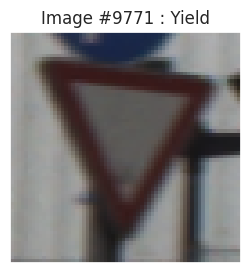

In [15]:
display_random_image(classes, train_images, train_labels)

In [16]:
def display_examples(class_names, images, labels):
    """
        Display 25 images from the images array with its corresponding labels
    """

    fig = plt.figure(figsize=(20,20))
    fig.suptitle("Some examples of images of the dataset", fontsize=16)
    for i in range(25):
        plt.subplot(5,5,i+1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(images[i])  # RGB image, no cmap
        plt.xlabel(classes[labels[i]])
    plt.show()

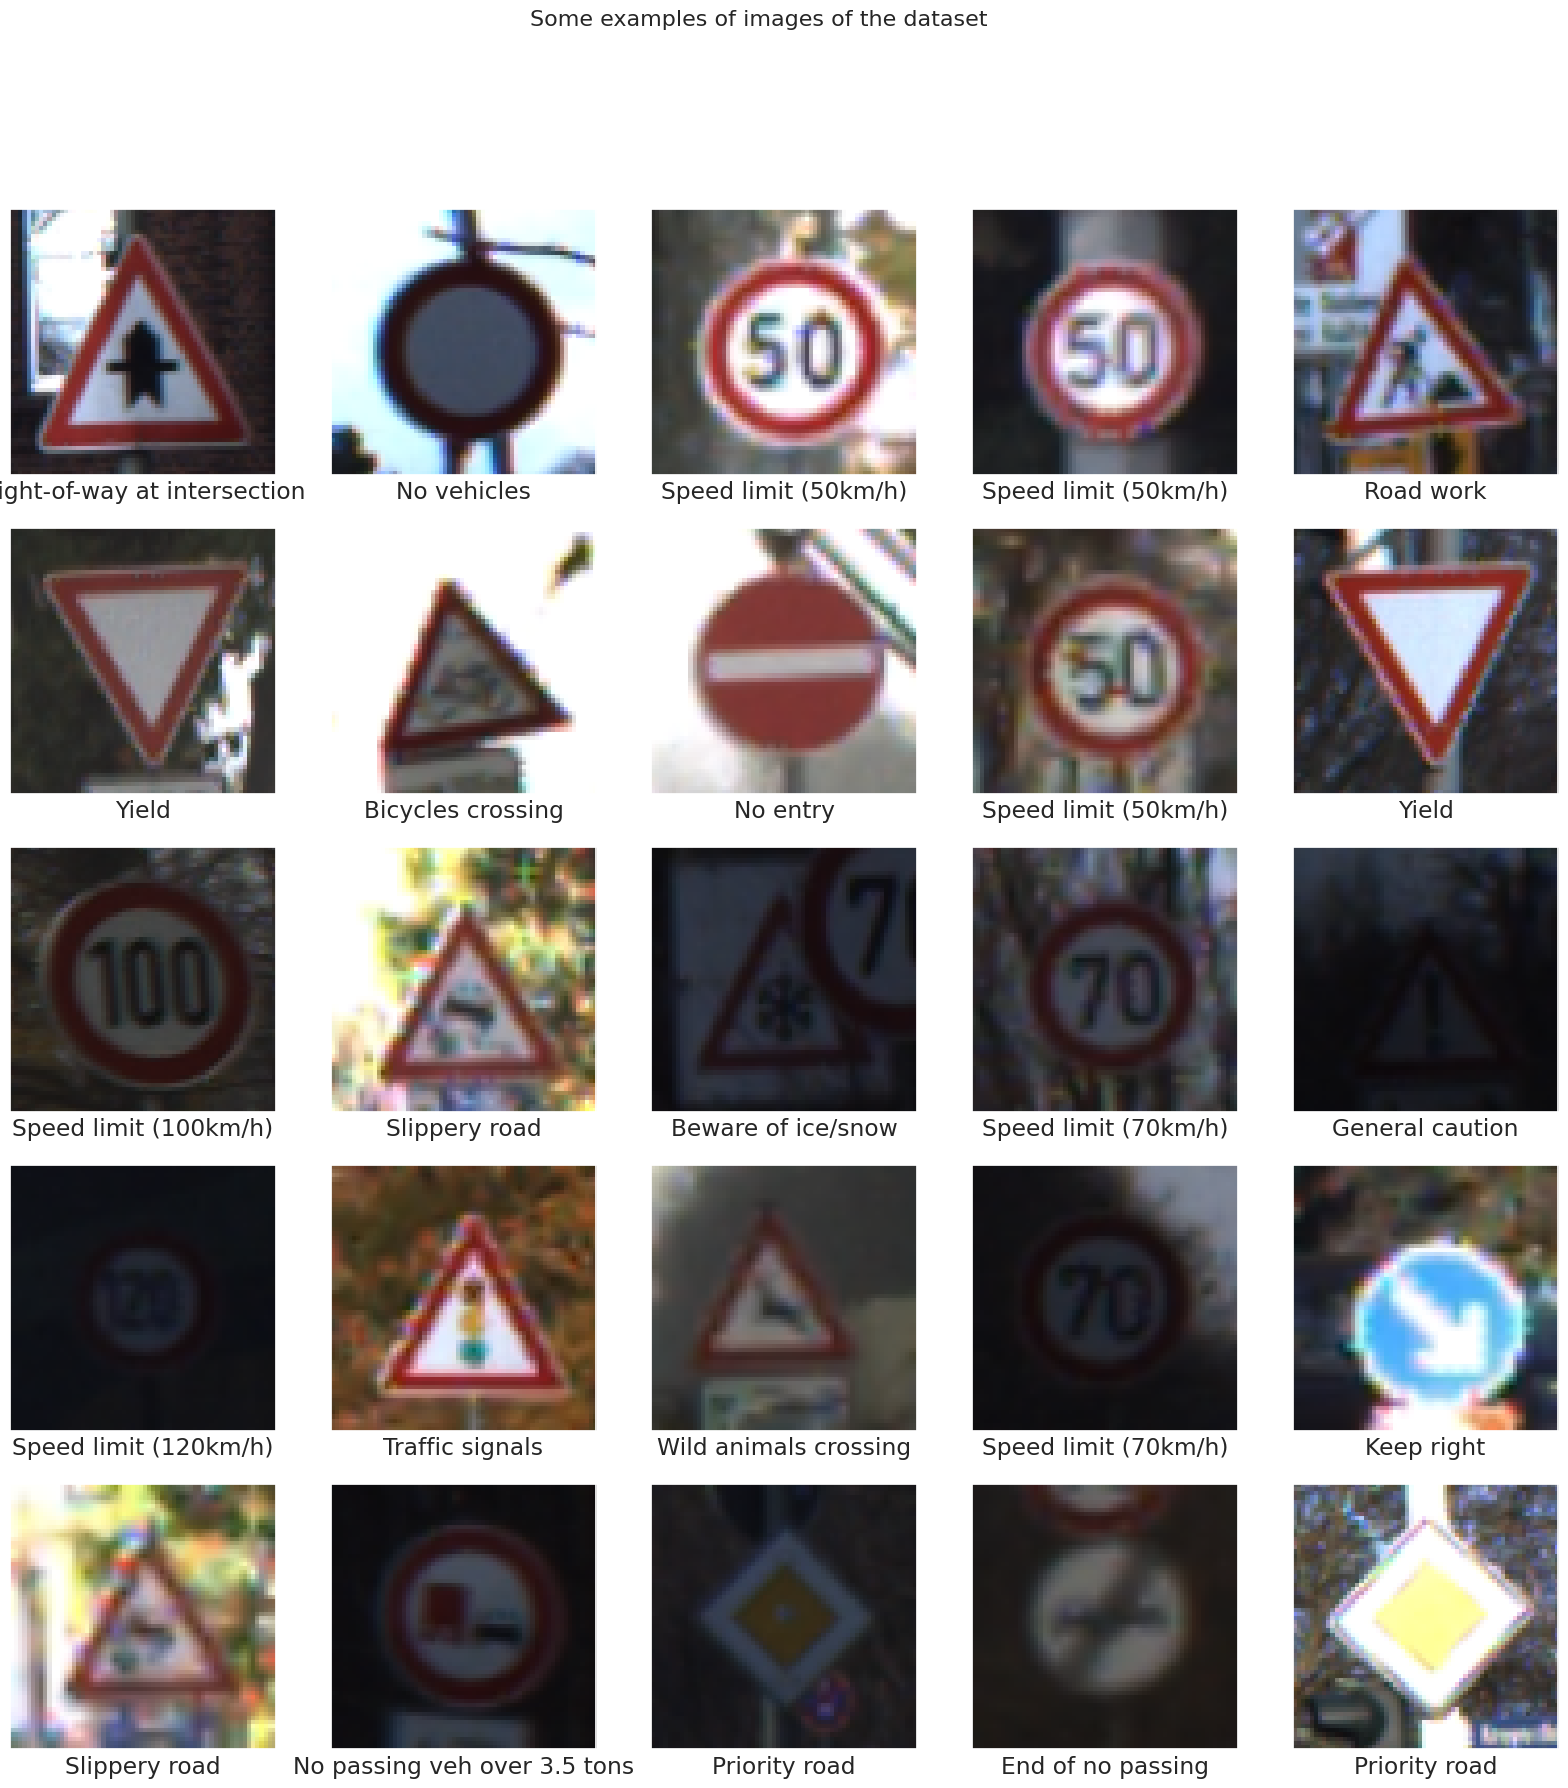

In [17]:
display_examples(classes, train_images, train_labels)

CNN MODEL


In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout, BatchNormalization



# Building the model
model = Sequential()
model.add(Conv2D(filters=32, kernel_size=(5,5), activation='relu', input_shape=train_images.shape[1:]))
model.add(Conv2D(filters=64, kernel_size=(5,5), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(rate=0.15))
model.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu'))
model.add(Conv2D(filters=256, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(rate=0.20))
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dropout(rate=0.25))
model.add(Dense(43, activation='softmax'))

# Compilation of the model
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

#M odel display
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 60, 60, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 56, 56, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,874,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │        22,059 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,319,659 (73.70 MB)

 Trainable params: 19,319,659 (73.70 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# Training the Model
with tf.device('/GPU:0'):
    epochs = 35
    history1 = model.fit(train_images, train_labels, batch_size=128, epochs=epochs, validation_data=(test_images, test_labels))

Epoch 1/35
307/307 ━━━━━━━━━━━━━━━━━━━━ 48s 113ms/step - accuracy: 0.4442 - loss: 2.0920 - val_accuracy: 0.9138 - val_loss: 0.3472
Epoch 2/35
307/307 ━━━━━━━━━━━━━━━━━━━━ 22s 73ms/step - accuracy: 0.9557 - loss: 0.1485 - val_accuracy: 0.9470 - val_loss: 0.2112
Epoch 3/35
307/307 ━━━━━━━━━━━━━━━━━━━━ 23s 74ms/step - accuracy: 0.9812 - loss: 0.0637 - val_accuracy: 0.9454 - val_loss: 0.2127
Epoch 4/35
307/307 ━━━━━━━━━━━━━━━━━━━━ 23s 74ms/step - accuracy: 0.9860 - loss: 0.0462 - val_accuracy: 0.9495 - val_loss: 0.2052
Epoch 5/35
307/307 ━━━━━━━━━━━━━━━━━━━━ 23s 74ms/step - accuracy: 0.9874 - loss: 0.0380 - val_accuracy: 0.9618 - val_loss: 0.1838
Epoch 6/35
307/307 ━━━━━━━━━━━━━━━━━━━━ 23s 75ms/step - accuracy: 0.9905 - loss: 0.0301 - val_accuracy: 0.9655 - val_loss: 0.1590
Epoch 7/35
307/307 ━━━━━━━━━━━━━━━━━━━━ 23s 74ms/step - accuracy: 0.9926 - loss: 0.0215 - val_accuracy: 0.9620 - val_loss: 0.1730
Epoch 8/35
307/307 ━━━━━━━━━━━━━━━━━━━━ 23s 75ms/step - accuracy: 0.9941 - loss: 0.0190 -

PLOT Accuracy

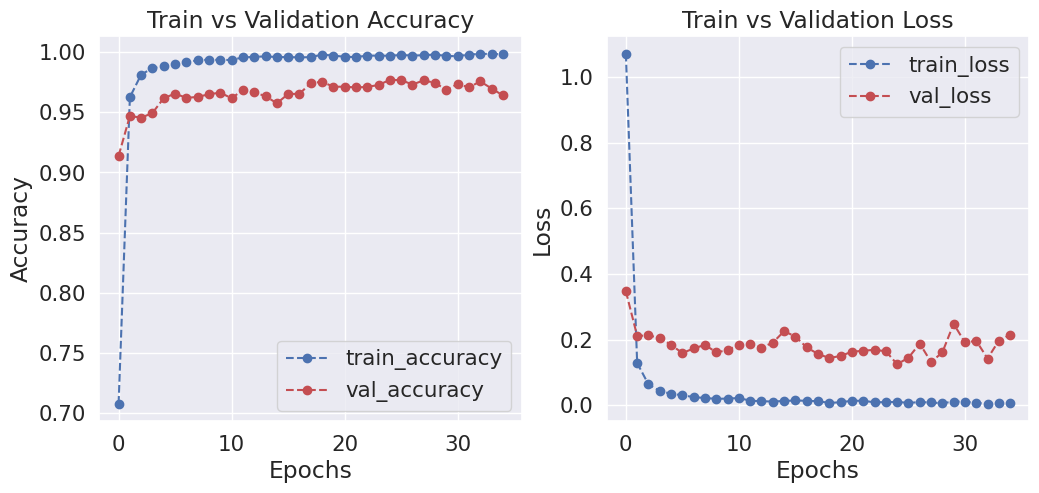

In [20]:
def plot_accuracy_loss(history):
    """
    Plot the accuracy and the loss during the training of the nn.
    """
    fig = plt.figure(figsize=(12,5))

    # Plot accuracy
    plt.subplot(1,2,1)
    plt.plot(history1.history['accuracy'], 'bo--', label='train_accuracy')
    plt.plot(history1.history['val_accuracy'], 'ro--', label='val_accuracy')
    plt.title("Train vs Validation Accuracy")
    plt.ylabel("Accuracy")
    plt.xlabel("Epochs")
    plt.legend()

    # Plot loss function
    plt.subplot(1,2,2)
    plt.plot(history1.history['loss'], 'bo--', label='train_loss')
    plt.plot(history1.history['val_loss'], 'ro--', label='val_loss')
    plt.title("Train vs Validation Loss")
    plt.ylabel("Loss")
    plt.xlabel("Epochs")
    plt.legend()

    plt.show()


plot_accuracy_loss(history1)

Predictions

In [21]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns


pred_probs = model.predict(test_images)
pred_labels = np.argmax(pred_probs, axis=1)

395/395 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step


Classification Report

In [22]:
classes = [str(i) for i in range(43)]

print("Classification Report:")
print(classification_report(test_labels, pred_labels, target_names=classes))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        60
           1       0.97      0.99      0.98       720
           2       0.97      0.98      0.98       750
           3       0.95      0.97      0.96       450
           4       1.00      0.97      0.98       660
           5       0.89      0.95      0.92       630
           6       1.00      0.85      0.92       150
           7       0.97      0.92      0.95       450
           8       0.99      0.92      0.95       450
           9       0.96      1.00      0.98       480
          10       0.99      1.00      0.99       660
          11       0.92      0.96      0.94       420
          12       0.99      0.99      0.99       690
          13       0.99      1.00      0.99       720
          14       0.98      1.00      0.99       270
          15       1.00      1.00      1.00       210
          16       1.00      0.98      0.99       150
    

Confusion Matrix


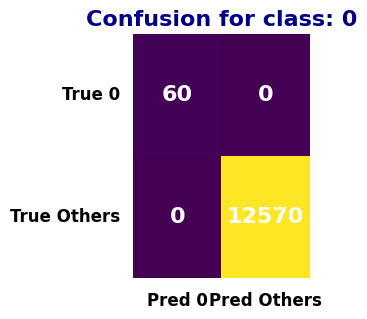

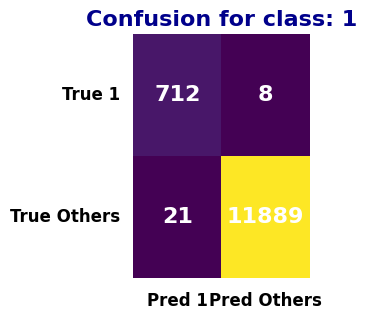

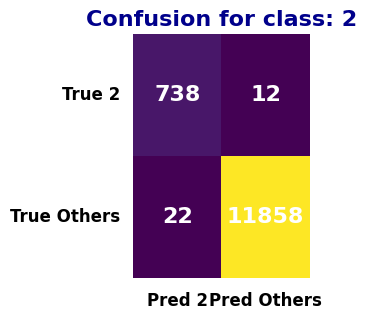

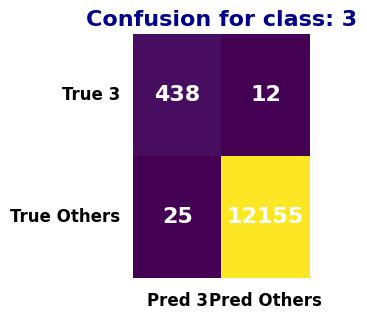

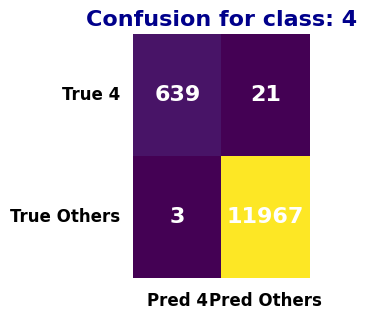

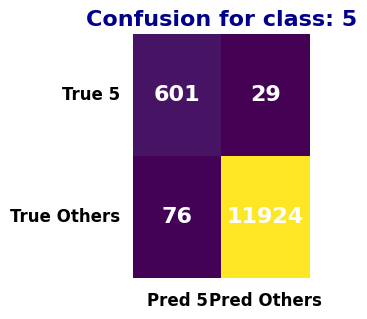

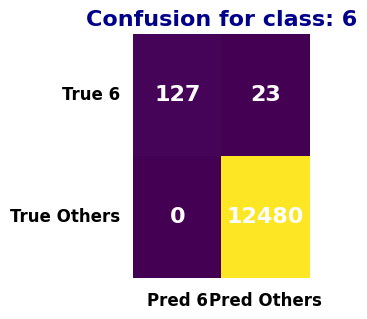

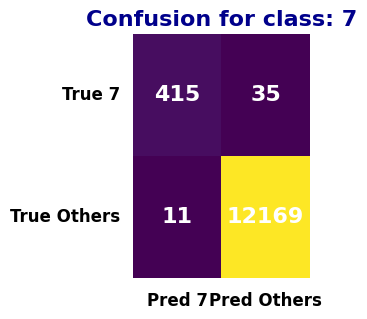

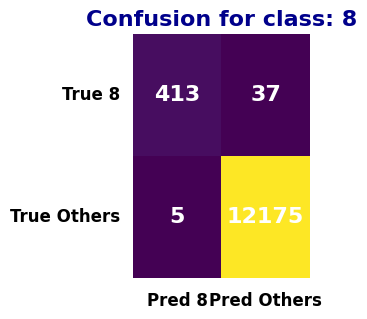

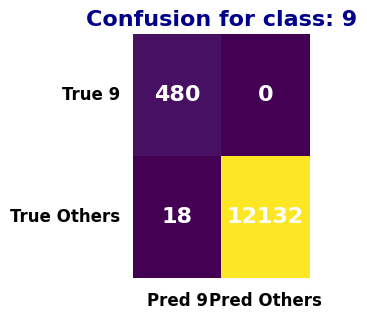

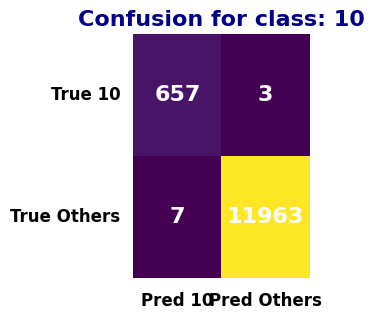

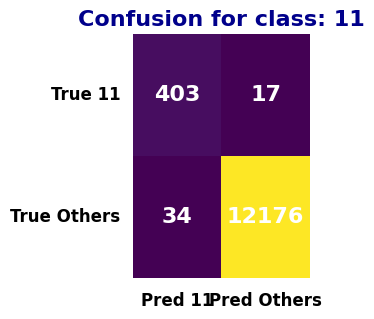

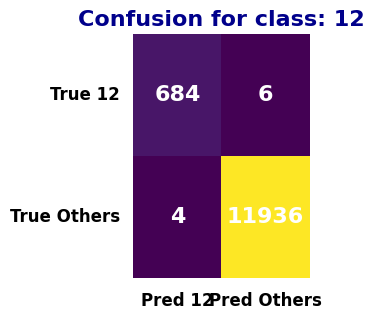

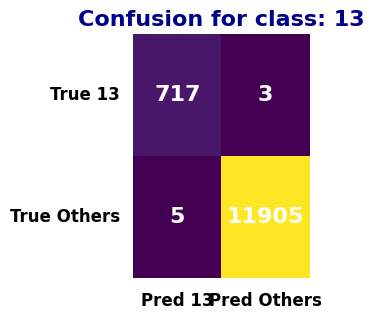

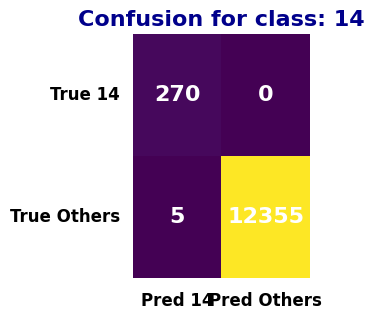

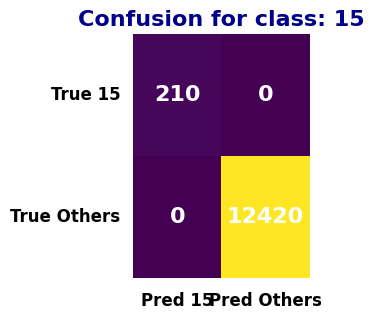

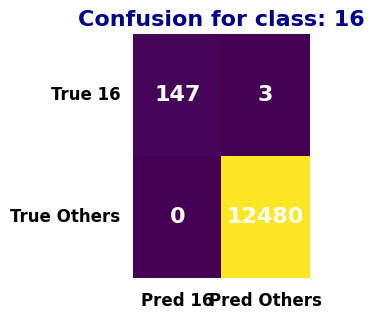

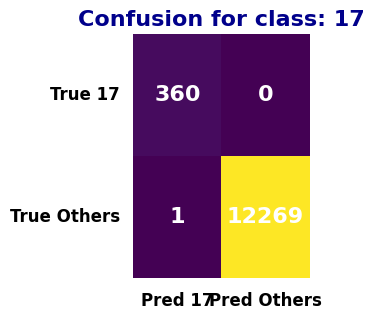

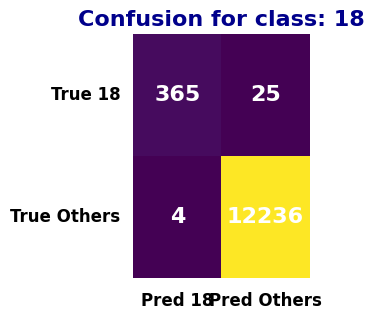

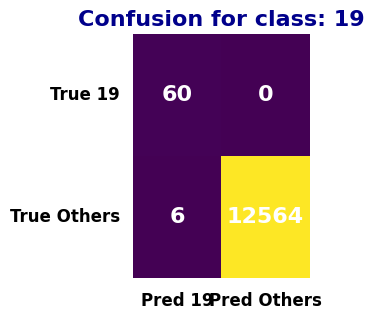

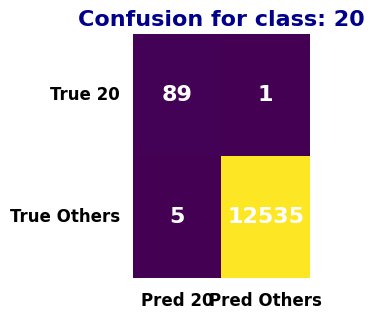

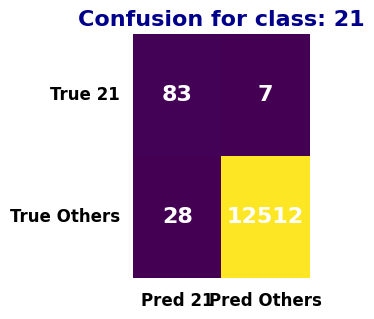

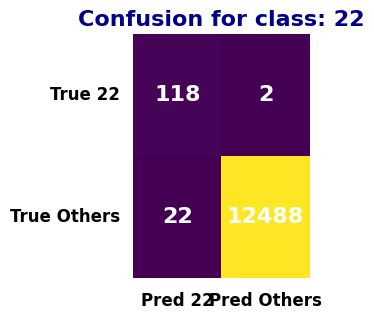

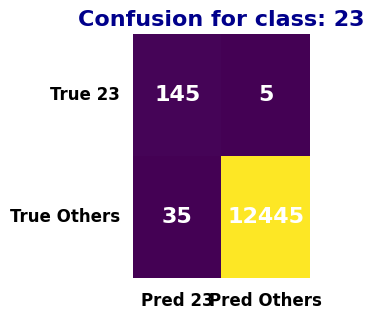

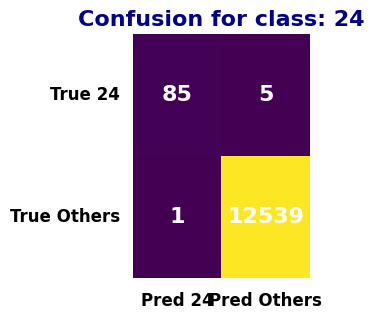

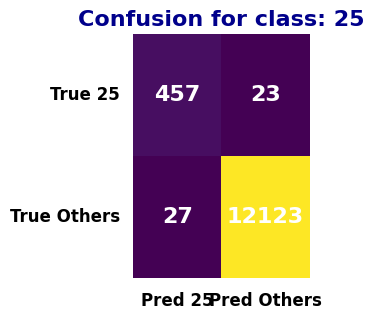

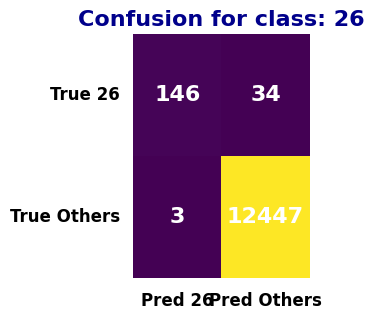

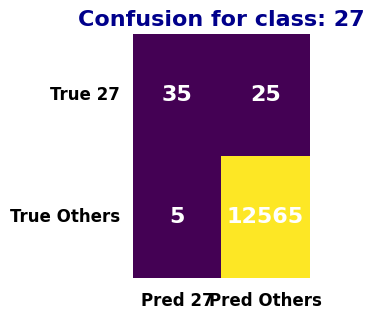

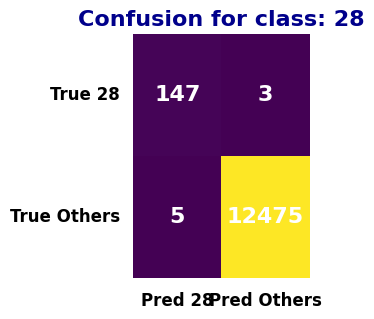

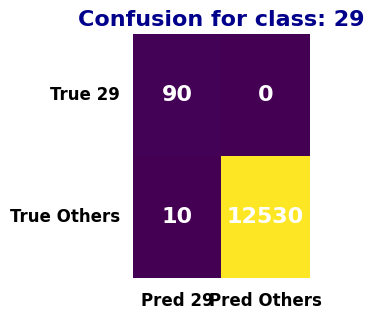

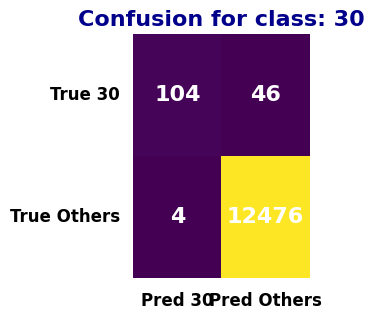

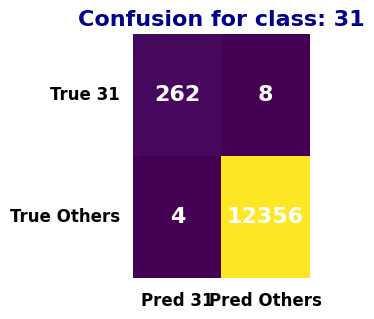

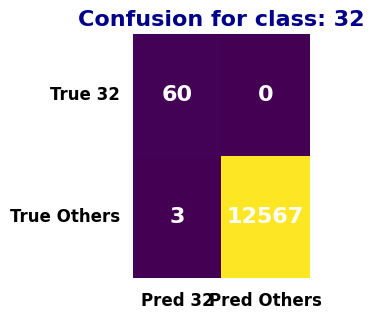

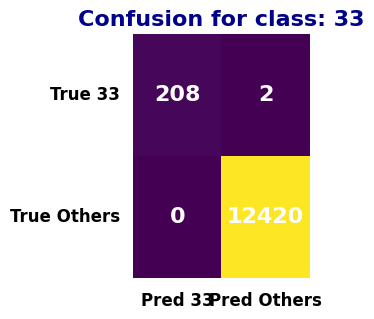

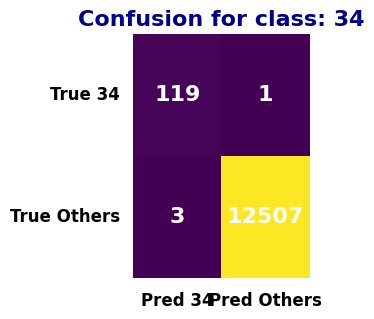

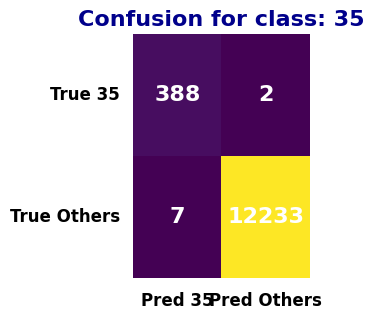

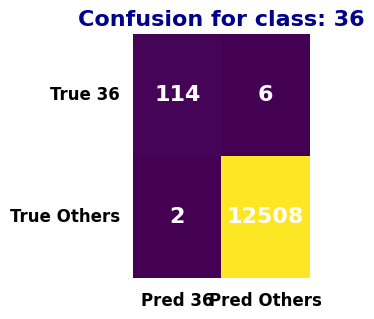

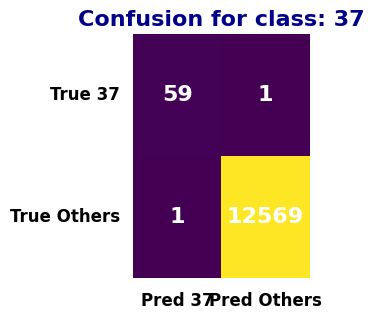

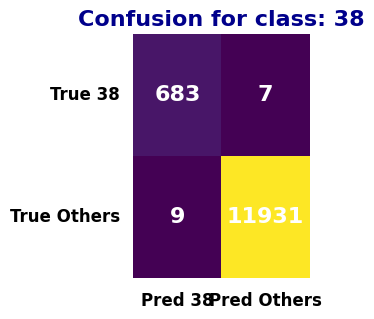

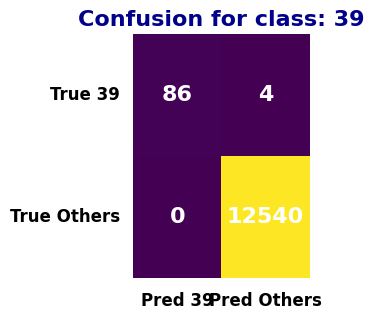

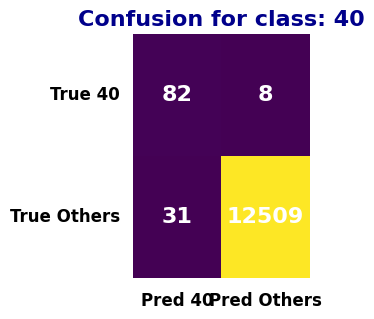

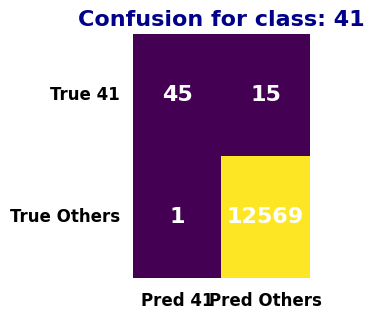

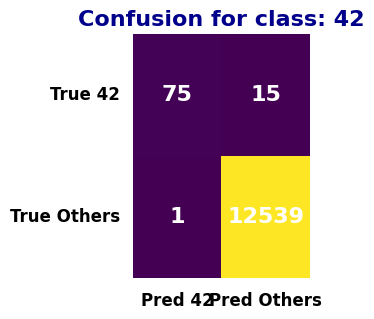

In [23]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(test_labels, pred_labels)

for i, cls in enumerate(classes):
    plt.figure(figsize=(3.5,3.5))

    # بناء مصفوفة 2x2 للكلاس
    cm_class = [[cm[i,i], cm[i].sum() - cm[i,i]],
                [cm[:,i].sum() - cm[i,i], cm.sum() - cm[i].sum() - cm[:,i].sum() + cm[i,i]]]

    # رسم
    ax = sns.heatmap(cm_class, annot=True, fmt="d", cmap="viridis", cbar=False,
                     xticklabels=[f"Pred {cls}", "Pred Others"],
                     yticklabels=[f"True {cls}", "True Others"],
                     annot_kws={"size":16, "weight":"bold", "color":"white"})  # أرقام كبيرة وBold

    plt.title(f"Confusion for class: {cls}", fontsize=16, weight="bold", color="darkblue")
    plt.xticks(fontsize=12, weight="bold", color="black")
    plt.yticks(fontsize=12, weight="bold", color="black", rotation=0)
    plt.tight_layout()
    plt.show()

395/395 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step


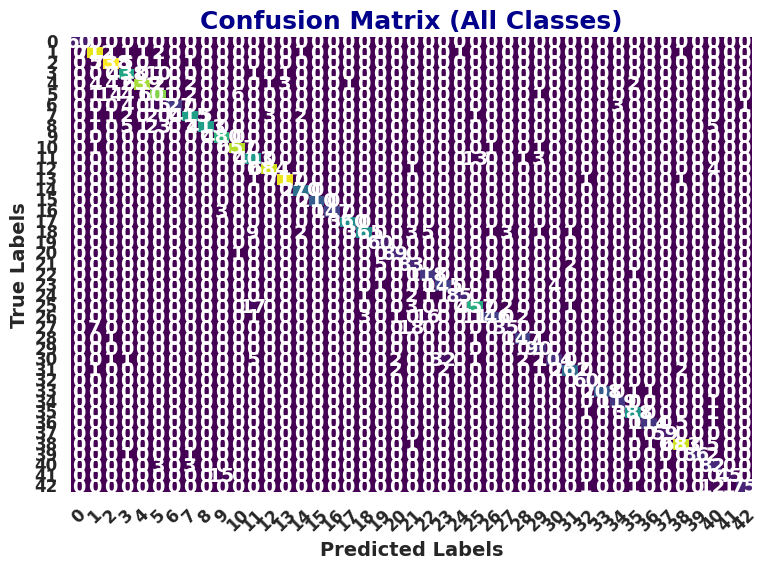

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import cv2


data_dir = "/content/gtsrb-german-traffic-sign"
test_csv  = pd.read_csv(os.path.join(data_dir, "Test.csv"))

IMAGE_SIZE = (64, 64)
def load_data(df, base_dir):
    images = []
    labels = []

    for i, row in df.iterrows():
        img_path = os.path.join(base_dir, row["Path"])
        label = row["ClassId"]

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, IMAGE_SIZE)

        # Normalization
        image = image.astype("float32") / 255.0

        images.append(image)
        labels.append(label)

    images = np.array(images, dtype="float32")
    labels = np.array(labels, dtype="int32")
    return images, labels

test_images, test_labels = load_data(test_csv, data_dir)

pred_probs = model.predict(test_images)
pred_labels = np.argmax(pred_probs, axis=1)


# Compute confusion matrix
cm = confusion_matrix(test_labels, pred_labels)

# Plot all classes together
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", cbar=False,
            xticklabels=[str(i) for i in range(43)], yticklabels=[str(i) for i in range(43)],
            annot_kws={"size":14, "weight":"bold", "color":"white"})

plt.title("Confusion Matrix (All Classes)", fontsize=18, weight="bold", color="darkblue")
plt.xlabel("Predicted Labels", fontsize=14, weight="bold")
plt.ylabel("True Labels", fontsize=14, weight="bold")
plt.xticks(fontsize=12, rotation=45, weight="bold")
plt.yticks(fontsize=12, rotation=0, weight="bold")
plt.tight_layout()
plt.show()

In [ ]:
model.save("traffic_sign_model.h5")
